In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\verma\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2 .csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66
3,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 500(418.06 sq.m.),5,7,3+,2.0,NaN,Moderately Old,NaN,500.0,NaN,1,1,1,1,0,2,70
4,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82


In [5]:
df.shape

(3677, 23)

In [6]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

# Price

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price', ylabel='Density'>

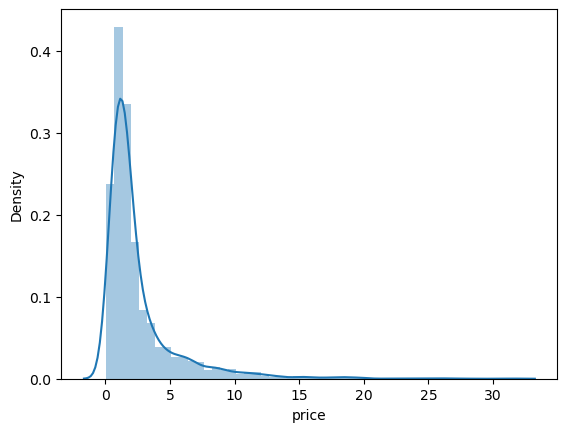

In [7]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

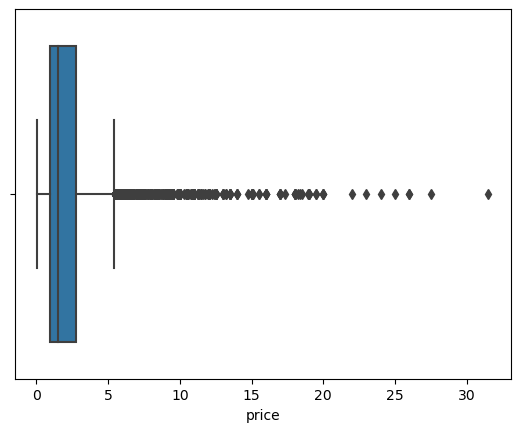

In [8]:
sns.boxplot(x=df['price'])

In [9]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [10]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2029,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,1,74
1823,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42
1702,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
728,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,138
1022,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
948,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
3174,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,2,145
1905,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
595,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,1,97
438,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,153


In [11]:
outliers.sort_values('price',ascending=False).to_csv('OUTLIERS1.csv',index=False)

In [12]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_per_sqft', ylabel='Density'>

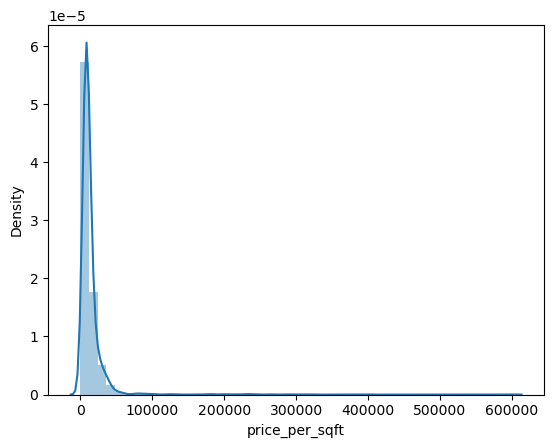

In [13]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

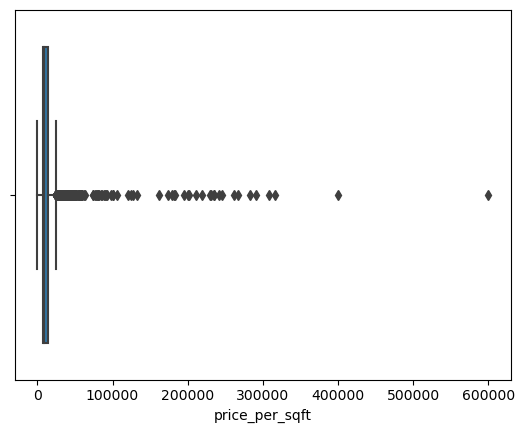

In [14]:
sns.boxplot(x=df['price_per_sqft'])

In [15]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [16]:
outliers_sqft.sort_values('price_per_sqft',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
948,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
1257,house,dlf city plots phase 2,sector 25,10.00,400000.0,250.0,Plot area 250(23.23 sq.m.),12,12,3+,4.0,North,Relatively New,NaN,250.0,NaN,1,1,0,0,0,2,114
707,house,independent,sector 12,6.00,315789.0,190.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,9,6,2,2.0,North-East,Old Property,NaN,NaN,1600.0,0,0,0,0,0,0,0
886,house,ansal,sector 43,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53
2979,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),12,12,3+,NaN,West,Moderately Old,NaN,232.0,NaN,1,1,0,1,1,2,49
1035,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),3,3,3,1.0,East,Moderately Old,NaN,240.0,NaN,0,1,0,0,0,0,49
488,house,independent,sector 57,8.00,266666.0,300.0,Plot area 300(27.87 sq.m.),5,4,3,2.0,North,Relatively New,NaN,300.0,NaN,1,1,0,1,0,0,21
3153,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,2.0,East,Old Property,NaN,402.0,NaN,0,1,0,1,0,2,91
1990,house,huda plot sector 38,sector 38,4.30,245398.0,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,5.0,North-West,Relatively New,NaN,145.0,NaN,0,0,0,0,0,1,7
931,house,independent,sector 55,1.45,241666.0,60.0,Plot area 60(5.57 sq.m.),4,4,3+,4.0,East,Relatively New,NaN,60.0,NaN,0,0,1,0,0,0,70


In [17]:
# outliers_sqft.sort_values('price_per_sqft',ascending=False).to_csv('outliers_sqft.csv',index=False)

In [18]:
# After Spending some time with data i get to know that
# The Values in area columns which are less than 1000 that are in sq_yards so i have to convert it into sq_ft
# 1 sq_yards into 9sq_ft

In [19]:
# convert the area value inton sq_ft but only for a outlier data
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2165031417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [20]:
# here i have recalculated the the price_per_sqft only for the outliers data
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\1456879321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [21]:
# 3150.0*26.00

In [22]:
outliers_sqft.sort_values('price_per_sqft',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1702,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
948,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
152,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
1936,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,2,160
2119,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,2,103
1401,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,1,72
2520,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0
728,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,138
1994,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,1,75
1149,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0


In [23]:
# Now here ouer mean and median are approximately equal and max price get so reduced
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [24]:
# Now making changes in original data Frame
df.update(outliers_sqft)

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2451507319.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_per_sqft', ylabel='Density'>

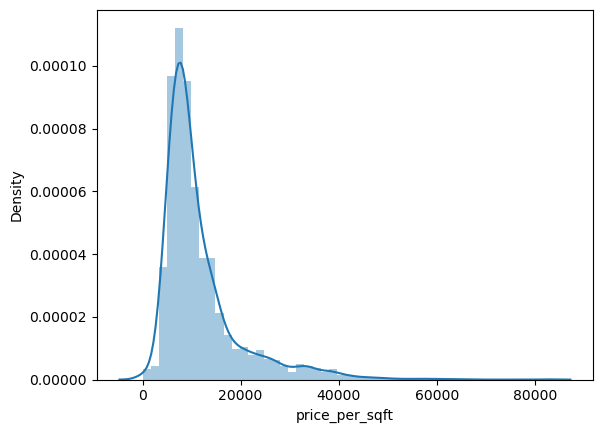

In [25]:

sns.distplot(df['price_per_sqft'])

In [26]:
df['price_per_sqft'].skew()

2.4063837889604796

<Axes: xlabel='price_per_sqft'>

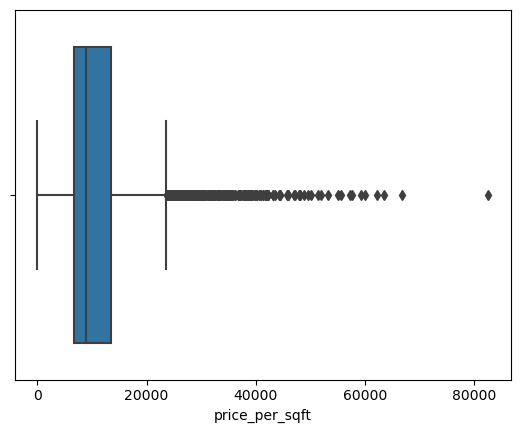

In [27]:
sns.boxplot(x=df['price_per_sqft'])

In [28]:
# Now i check the price_per_sqft for more than 50000
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
152,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
308,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,153
728,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,138
948,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,2,122
1149,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0
1401,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,1,72
1495,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,2,99
1702,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
1936,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,2,160
1994,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,3240.0,NaN,1,1,0,1,0,1,75


In [29]:
# Total 13 rows are there whose price is more than 50000
df[df['price_per_sqft']>50000].shape

(13, 23)

In [30]:
# here i have excluded these 13 row from the data
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

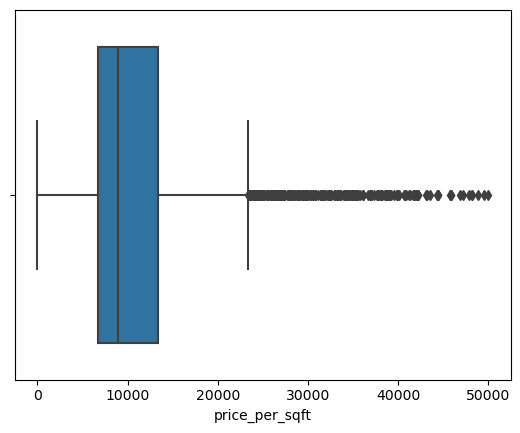

In [31]:
sns.boxplot(x=df['price_per_sqft'])

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2451507319.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_per_sqft', ylabel='Density'>

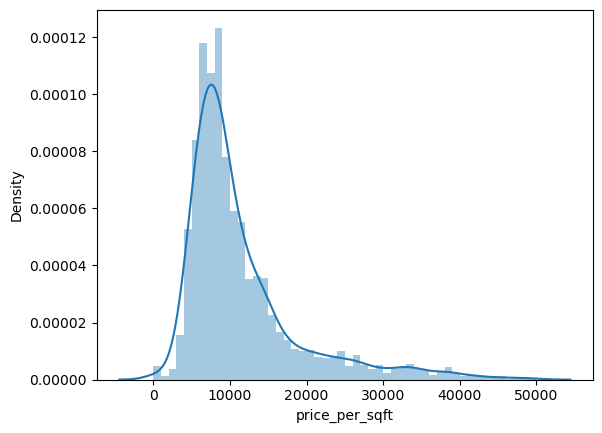

In [32]:

sns.distplot(df['price_per_sqft'])

In [33]:
df['price_per_sqft'].skew()

2.0364072843274155

In [34]:
df['price_per_sqft'].describe()

count     3647.000000
mean     11474.143406
std       7598.603380
min          4.000000
25%       6735.000000
50%       8916.000000
75%      13383.000000
max      50000.000000
Name: price_per_sqft, dtype: float64

# Area

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\1761899025.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='area', ylabel='Density'>

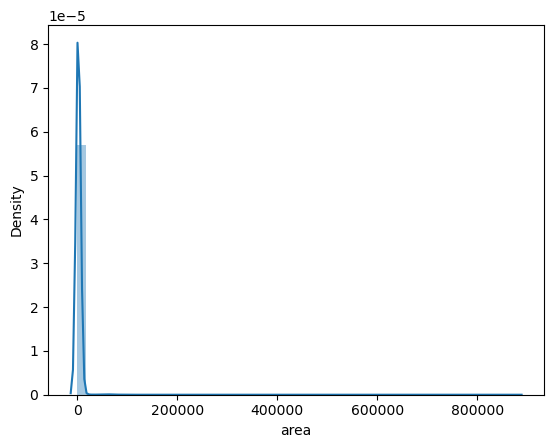

In [35]:
# here again the crazy distribution in area column
sns.distplot(df['area'])

In [36]:
df['area'].skew()

29.67273999907765

<Axes: xlabel='area'>

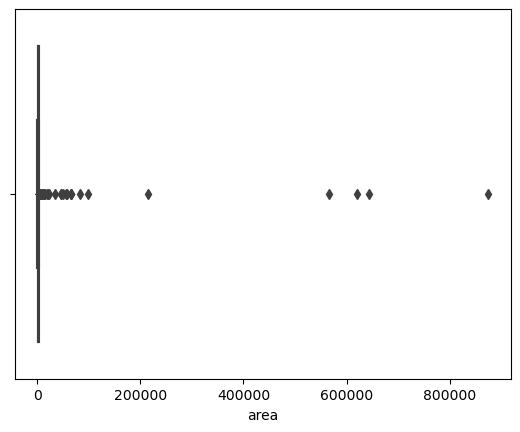

In [37]:
# here are few area values which is greater than 800000 sq_ft 
sns.boxplot(x=df['area'])

In [38]:
df['area'].describe()

count      3647.000000
mean       2947.723608
std       23208.194102
min         145.000000
25%        1262.000000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [39]:
# here are only few data whouse area is greater than 100000
# and the anamoly in the data is getting this muchh bigger area in very low price
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
881,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,1,44
1159,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
1615,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,2,0
2267,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
3368,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65


In [40]:
# here i am dropping those are whose area is greater than 100000 from the original dasta
df = df[df['area'] < 100000]

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='area', ylabel='Density'>

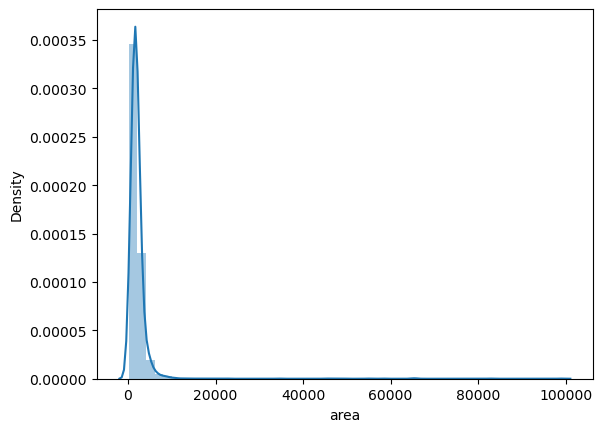

In [41]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

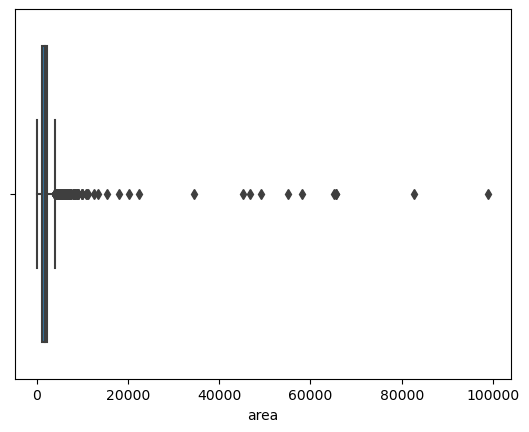

In [42]:
sns.boxplot(x=df['area'])

In [43]:
# Now here i have find those values whose area is greater than 10000 because 10000 is also a very greater area
df[df['area'] > 10000].sort_values('area',ascending=False)

# After starring the data i have noticed that anamolies in the prices
# 700, 2591, 1952, 1372, 418, 2179, 1597, 3014, 70

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
700,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,2,60
1643,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2591,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
1952,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
127,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
1372,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
418,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
2179,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
2905,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109
1597,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [44]:
# dropping these anamolies from the data
df.drop(index=[700, 2591, 1952, 1372, 418, 2179, 1597, 3014, 70], inplace=True)

In [45]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1643,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
127,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2905,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,2,109
46,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,2,61
3168,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,2,123
3617,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.00,1,0,0,1,1,2,44
2753,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.00,0,1,0,0,0,0,160
89,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
1823,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42
828,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [46]:
# df[df['area'] > 10000].sort_values('area',ascending=False)[['super_built_up_area','built_up_area','carpet_area']]

In [47]:
# these all are the data errors

df.loc[1643,'area'] = 115*9 # Built_up_area (here converting square yard into sq_ft)
df.loc[127,'area'] = 7250 # Carpet_area
df.loc[2905,'area'] = 5800 # Builtup area
df.loc[46,'area'] = 2660  # Built up area
df.loc[3168,'area'] = 2850 # Built up area
df.loc[3617,'area'] = 1812 # Carpet area
df.loc[2753,'area'] = 2160 # Built_up_area
df.loc[89,'area'] = 1175 # Carpet_area

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='area', ylabel='Density'>

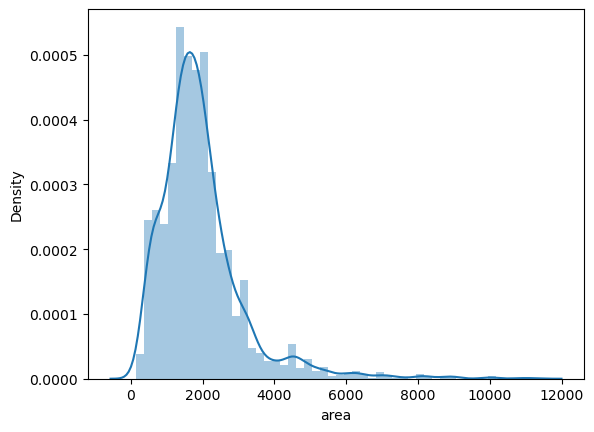

In [48]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

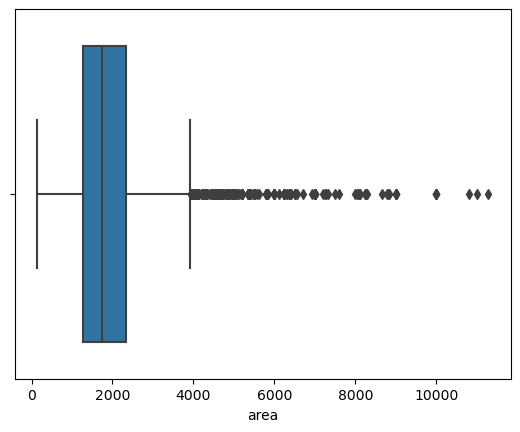

In [49]:
sns.boxplot(x=df['area'])

In [50]:
# Now it is showing more realistic number
df['area'].describe()

count     3633.000000
mean      1950.357005
std       1215.707897
min        145.000000
25%       1260.000000
50%       1747.000000
75%       2325.000000
max      11286.000000
Name: area, dtype: float64

### Bedroom

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='bedRoom', ylabel='Density'>

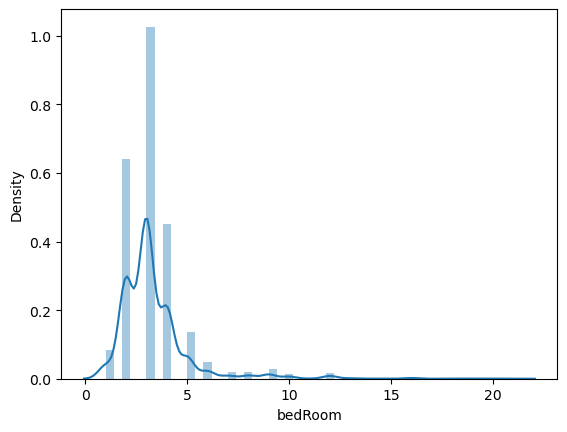

In [51]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

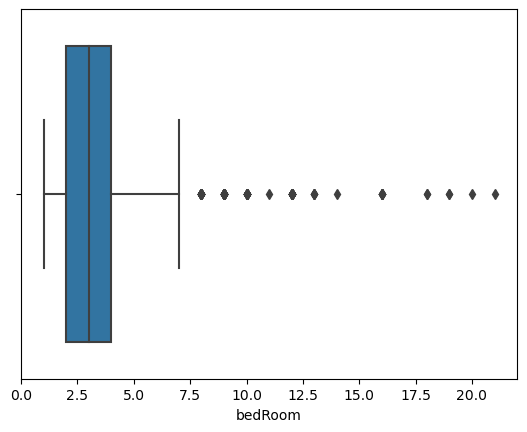

In [52]:
sns.boxplot(x=df['bedRoom'])

In [53]:
df['bedRoom'].describe()

count    3633.000000
mean        3.333609
std         1.830035
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [54]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
406,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,1,49
3428,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,1,22
2626,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
2766,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
2996,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,1,70
964,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,1,57
2641,house,independent,sector 11,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,Relatively New,NaN,1800.0,NaN,0,0,0,0,0,2,20
438,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,153
474,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,2,31
1550,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,0,41


In [55]:
df = df[df['bedRoom'] <= 10]

In [56]:
df.shape

(3588, 23)

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='bedRoom', ylabel='Density'>

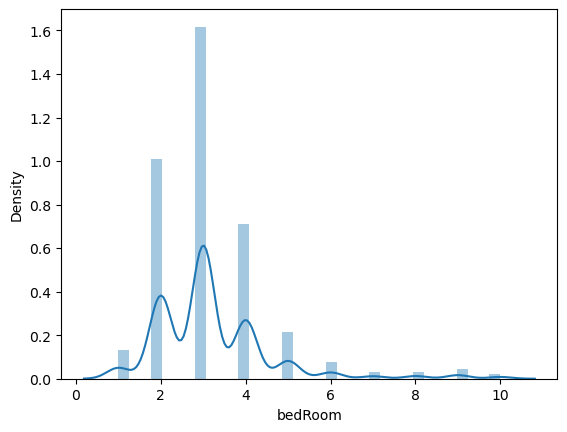

In [57]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

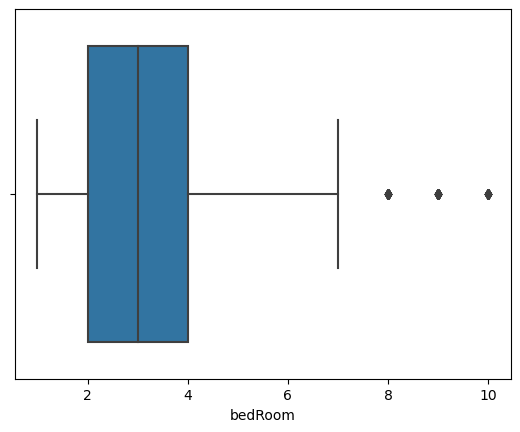

In [58]:
sns.boxplot(x=df['bedRoom'])

In [59]:
df['bedRoom'].describe()

count    3588.000000
mean        3.203735
std         1.393968
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='bathroom', ylabel='Density'>

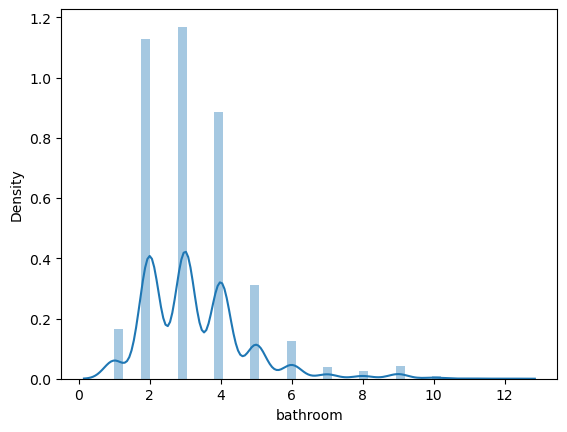

In [60]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

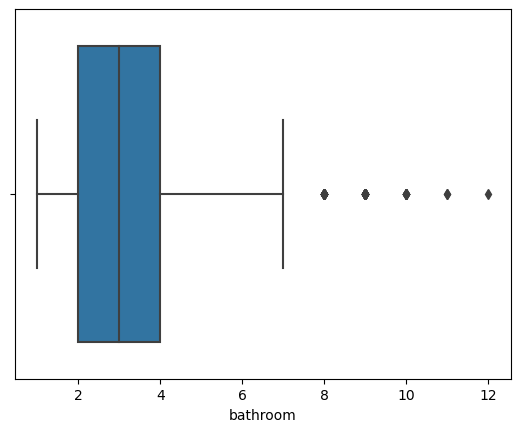

In [61]:
sns.boxplot(x=df['bathroom'])

In [62]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
571,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,2,146
581,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,2,39
3139,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,1,38


In [63]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66
4,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22


### super built up area

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='super_built_up_area', ylabel='Density'>

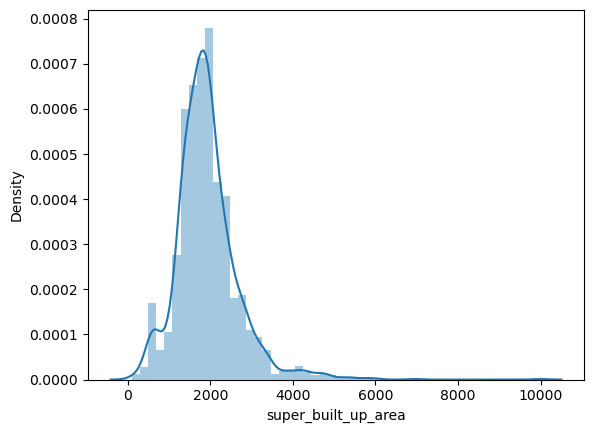

In [64]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

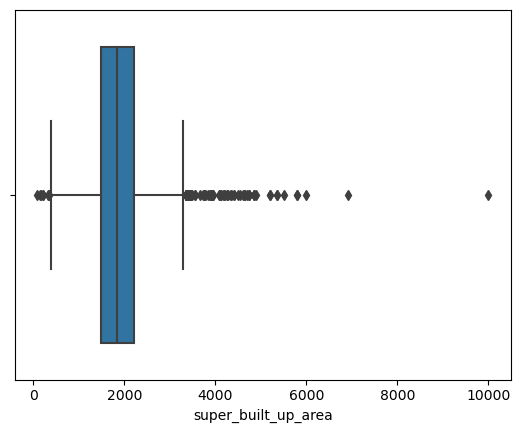

In [65]:
sns.boxplot(x=df['super_built_up_area'])

In [66]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [67]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1983,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49
2230,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,2,140


### built up area

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='built_up_area', ylabel='Density'>

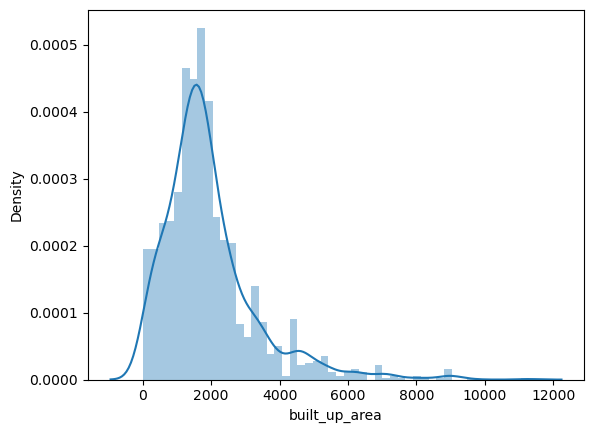

In [68]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

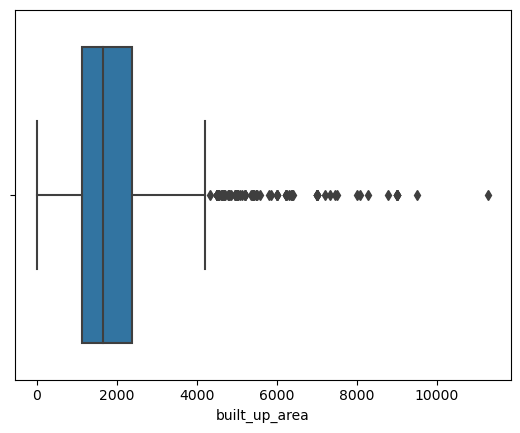

In [69]:
sns.boxplot(x=df['built_up_area'])

In [70]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1823,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42


### carpet area

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='carpet_area', ylabel='Density'>

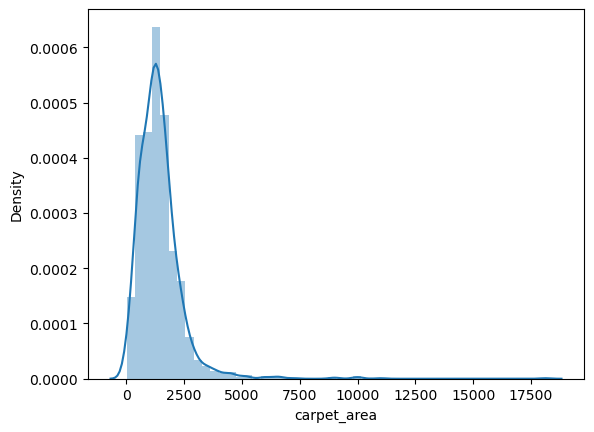

In [71]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

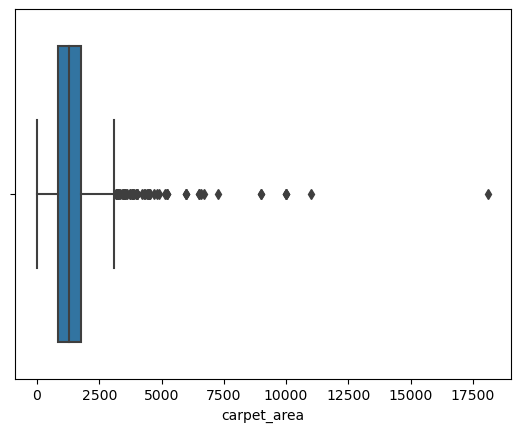

In [72]:
sns.boxplot(x=df['carpet_area'])

In [73]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
828,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
3617,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.0,1,0,0,1,1,2,44


In [74]:
df.loc[3617,'carpet_area'] = 1812

In [75]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
828,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [76]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11767.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66
4,flat,rof ananda,sector 95,0.46,6318.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22


# luxury_Score

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='luxury_score', ylabel='Density'>

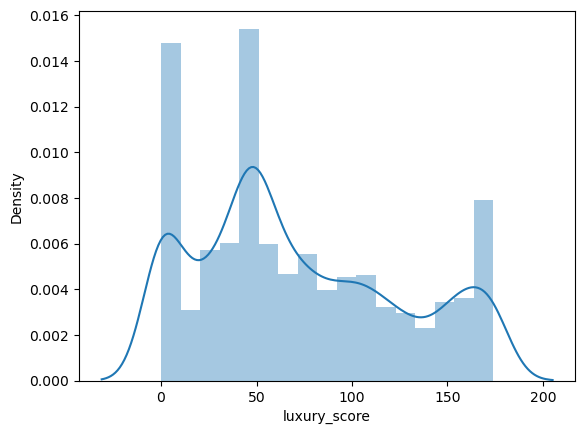

In [77]:
sns.distplot(df['luxury_score'])

<Axes: >

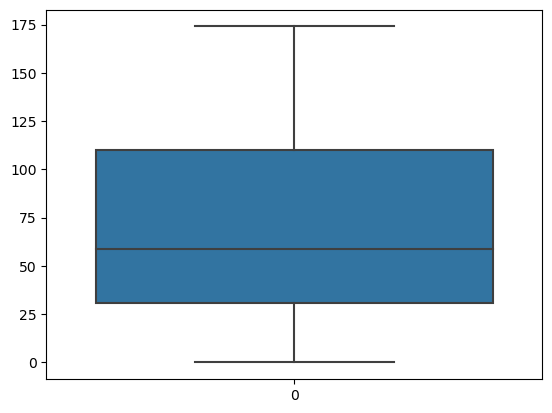

In [78]:
sns.boxplot(df['luxury_score'])

In [79]:
df.shape

(3588, 23)

In [80]:
# i was thinking to re calculate the price_per_sqft because we have made some changes in area values. 
# so because of that it may be some changes in price_per_sqft

In [81]:
# here i am re calculating the price_per_sqft

df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [82]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66
4,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22


C:\Users\verma\AppData\Local\Temp\ipykernel_20688\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])
C:\Users\verma\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='price_per_sqft', ylabel='Density'>

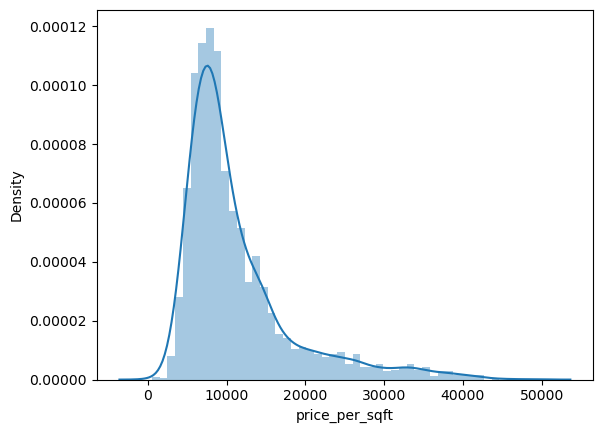

In [83]:
sns.distplot(df['price_per_sqft'])

<Axes: >

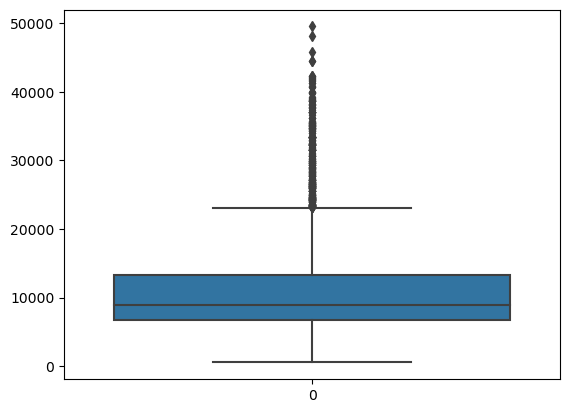

In [84]:
sns.boxplot(df['price_per_sqft'])

In [85]:
# here i have notice some data errors between area and bedrooms because i lesser area so many bedrooms are not possible
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
595,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,1,97
958,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,2,121
1201,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,0,0
2633,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,2,60
2640,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,2,44
2944,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,2,7
3085,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,2,103
3193,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,1,0
3644,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,2,88


In [86]:
# Here i am finding the ratio between area & bedroom so that i am able to detect the data errors 
# fornthat i have selected the fair price_per_sqft value
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

250.5

In [87]:
df[(df['area']/df['bedRoom'])<250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.000000,0,0,0,1,0,0,22
56,flat,prime habitat,sector 99a,0.27,6054.0,446.0,Carpet area: 448 (41.62 sq.m.),2,2,1,10.0,South,Relatively New,NaN,NaN,448.000000,0,0,0,0,0,0,67
58,house,huda floor,sector 38,4.00,22222.0,1800.0,Plot area 1800(167.23 sq.m.)Built Up area: 480...,9,9,3+,2.0,East,Relatively New,NaN,4800.0,3800.000000,0,0,1,1,0,2,152
65,house,independent,sector 10a,3.60,19608.0,1836.0,Plot area 204(170.57 sq.m.),8,4,3,3.0,North,Moderately Old,NaN,1836.0,NaN,0,0,0,1,0,2,28
88,house,my home,new sector 2,0.34,12593.0,270.0,Plot area 270(25.08 sq.m.),2,2,2,3.0,West,Moderately Old,NaN,270.0,NaN,0,0,0,0,0,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,house,independent,sector 3 phase 3 extension,0.50,11111.0,450.0,Plot area 450(41.81 sq.m.),5,3,3,3.0,NaN,Moderately Old,NaN,450.0,NaN,0,0,0,0,0,0,0
3728,house,ss omnia,sector 86,0.42,9333.0,450.0,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,NaN,50.0,NaN,0,0,0,0,0,0,0
3739,flat,mvn athens,sohna road,0.25,5187.0,482.0,Carpet area: 481.73 (44.75 sq.m.),2,2,1,3.0,East,Relatively New,NaN,NaN,481.684525,0,0,0,0,0,0,51
3771,house,independent,sector 7,0.90,10000.0,900.0,Plot area 100(83.61 sq.m.),6,4,3,3.0,North-East,Old Property,NaN,900.0,NaN,0,1,0,0,1,2,44


In [88]:
len(df[(df['area']/df['bedRoom'])<250])

185

In [89]:
df['area_room']=df['area']/df['bedRoom']
df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165,665.666667
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74,861.666667
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66,720.000000
4,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82,364.000000
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,135.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,flat,vatika emilia floors,sector 83,0.60,5714.0,1050.0,Super Built up area 1050(97.55 sq.m.)Built Up ...,2,2,2,1.0,South,Relatively New,1050.0,990.0,950.0,0,0,0,0,0,2,167,525.000000
3796,flat,unitech the residences,sector 33,1.35,8738.0,1545.0,Super Built up area 1545(143.54 sq.m.),3,4,2,8.0,North-East,Moderately Old,1545.0,NaN,NaN,0,1,0,0,0,0,49,515.000000
3798,flat,shree vardhman flora,sector 90,0.66,5077.0,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet a...,2,2,3,4.0,North-East,Relatively New,1300.0,NaN,960.0,1,0,0,0,0,0,119,650.000000
3801,flat,bestech park view city,sector 49,2.90,12170.0,2383.0,Super Built up area 2383(221.39 sq.m.),4,4,3+,5.0,South-West,Moderately Old,2383.0,NaN,NaN,0,1,0,0,0,0,117,595.750000


In [90]:
df.sort_values(by='area_room')

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
1499,house,independent,sector 28,0.75,20833.0,360.0,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,0,7,51.428571
132,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,450.0,NaN,0,0,0,1,0,0,7,64.285714
886,house,ansal,sector 43,1.85,34259.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53,67.500000
1365,house,independent,sector 105,0.60,11111.0,540.0,Plot area 60(50.17 sq.m.),8,4,3,3.0,West,New Property,NaN,540.0,NaN,0,0,0,0,0,0,17,67.500000
2257,house,independent,sector 6,0.50,13889.0,360.0,Plot area 40(33.45 sq.m.),5,3,3,3.0,NaN,Old Property,NaN,360.0,NaN,0,0,0,0,0,0,0,72.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616,flat,ramsons kshitij,sector 95,0.19,591.0,3215.0,Carpet area: 3212 (298.4 sq.m.),1,1,1,14.0,East,Relatively New,NaN,NaN,3212.0,0,0,0,0,0,0,49,3215.000000
2606,house,independent,sector 25,8.00,8000.0,10000.0,Carpet area: 10000 (929.03 sq.m.),3,9,2,3.0,NaN,New Property,NaN,NaN,10000.0,0,0,0,0,0,0,0,3333.333333
2209,house,independent,sohna road road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,NaN,3500.0,NaN,1,1,0,1,1,0,49,3599.666667
793,house,independent,sector 3,3.50,9211.0,3800.0,Built Up area: 3800 (353.03 sq.m.),1,1,0,1.0,NaN,Undefined,NaN,3800.0,NaN,0,0,0,0,0,0,0,3800.000000


In [91]:
360/7

51.42857142857143

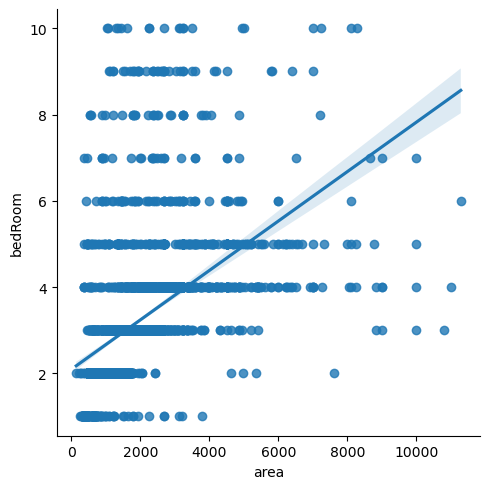

In [92]:
sns.lmplot(x='area',y='bedRoom',data=df);

In [93]:
# here i am dropping those data point which are data errors
df = df[df['area_room']>100]

In [94]:
# this also can be a data errors
outliers_df = df[(df['area_room']<250) & (df['bedRoom']>3)]
outliers_df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,5,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,135.000000
58,house,huda floor,sector 38,4.00,22222.0,1800.0,Plot area 1800(167.23 sq.m.)Built Up area: 480...,9,9,3+,2.0,East,Relatively New,NaN,4800.0,3800.0,0,0,1,1,0,2,152,200.000000
65,house,independent,sector 10a,3.60,19608.0,1836.0,Plot area 204(170.57 sq.m.),8,4,3,3.0,North,Moderately Old,NaN,1836.0,NaN,0,0,0,1,0,2,28,229.500000
100,house,iffco nagar and 17b rwa,sector 17,2.98,20566.0,1449.0,Plot area 161(134.62 sq.m.),6,6,3+,3.0,East,Relatively New,NaN,1449.0,NaN,1,0,0,1,0,0,78,241.500000
129,house,independent,sector 47,4.60,26620.0,1728.0,Plot area 192(160.54 sq.m.),7,6,3+,4.0,NaN,Moderately Old,NaN,1728.0,NaN,0,0,0,0,0,1,51,246.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3592,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
3615,house,independent,sector 38,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),7,7,3+,3.0,North-East,Relatively New,NaN,900.0,NaN,1,0,1,1,0,0,27,128.571429
3659,house,not applicable,sector 4,0.75,11719.0,640.0,Plot area 640(59.46 sq.m.),5,4,3,2.0,NaN,Moderately Old,NaN,640.0,NaN,0,0,0,0,0,0,0,128.000000
3689,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000


In [95]:
# here i am finding the no of rooms per floor
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])
outliers_df

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\1231268247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,2.0,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,135.000000
58,house,huda floor,sector 38,4.00,22222.0,1800.0,Plot area 1800(167.23 sq.m.)Built Up area: 480...,4.0,9,3+,2.0,East,Relatively New,NaN,4800.0,3800.0,0,0,1,1,0,2,152,200.000000
65,house,independent,sector 10a,3.60,19608.0,1836.0,Plot area 204(170.57 sq.m.),3.0,4,3,3.0,North,Moderately Old,NaN,1836.0,NaN,0,0,0,1,0,2,28,229.500000
100,house,iffco nagar and 17b rwa,sector 17,2.98,20566.0,1449.0,Plot area 161(134.62 sq.m.),2.0,6,3+,3.0,East,Relatively New,NaN,1449.0,NaN,1,0,0,1,0,0,78,241.500000
129,house,independent,sector 47,4.60,26620.0,1728.0,Plot area 192(160.54 sq.m.),2.0,6,3+,4.0,NaN,Moderately Old,NaN,1728.0,NaN,0,0,0,0,0,1,51,246.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3592,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5.0,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
3615,house,independent,sector 38,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),2.0,7,3+,3.0,North-East,Relatively New,NaN,900.0,NaN,1,0,1,1,0,0,27,128.571429
3659,house,not applicable,sector 4,0.75,11719.0,640.0,Plot area 640(59.46 sq.m.),2.0,4,3,2.0,NaN,Moderately Old,NaN,640.0,NaN,0,0,0,0,0,0,0,128.000000
3689,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8.0,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000


In [96]:
df.update(outliers_df)

In [97]:
# again i am calculating the ratio area room because we have made changes in the bedroom value
df['area_room']=df['area']/df['bedRoom']
df

C:\Users\verma\AppData\Local\Temp\ipykernel_20688\96610705.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room']=df['area']/df['bedRoom']


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165,665.666667
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74,861.666667
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66,720.000000
4,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82,364.000000
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,2,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,337.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,flat,vatika emilia floors,sector 83,0.60,5714.0,1050.0,Super Built up area 1050(97.55 sq.m.)Built Up ...,2,2,2,1.0,South,Relatively New,1050.0,990.0,950.0,0,0,0,0,0,2,167,525.000000
3796,flat,unitech the residences,sector 33,1.35,8738.0,1545.0,Super Built up area 1545(143.54 sq.m.),3,4,2,8.0,North-East,Moderately Old,1545.0,NaN,NaN,0,1,0,0,0,0,49,515.000000
3798,flat,shree vardhman flora,sector 90,0.66,5077.0,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet a...,2,2,3,4.0,North-East,Relatively New,1300.0,NaN,960.0,1,0,0,0,0,0,119,650.000000
3801,flat,bestech park view city,sector 49,2.90,12170.0,2383.0,Super Built up area 2383(221.39 sq.m.),4,4,3+,5.0,South-West,Moderately Old,2383.0,NaN,NaN,0,1,0,0,0,0,117,595.750000


In [98]:
# there are 13 data points
df[(df['area_room']<250) & (df['bedRoom']>4)].shape

(13, 24)

In [99]:
df.shape

(3568, 24)

In [101]:
# here i am excluding these 13 rows from the data
df = df[~((df['area_room']<250) & (df['bedRoom']>4))]
df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room
0,flat,the close north,sector 50,2.35,11768.0,1997.0,Super Built up area 1997(185.53 sq.m.)Built Up...,3,3,3+,8.0,North-East,Moderately Old,1997.0,1950.0,1850.0,0,0,0,0,0,2,165,665.666667
1,flat,ats tourmaline,sector 109,2.30,8897.0,2585.0,Super Built up area 2585(240.15 sq.m.),3,4,3+,10.0,East,New Property,2585.0,NaN,NaN,0,1,0,0,1,0,74,861.666667
2,house,unitech espace,sector 50,7.50,34722.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 241 ...,3,3,2,2.0,West,Moderately Old,NaN,241.0,240.0,0,1,0,0,0,2,66,720.000000
4,flat,rof ananda,sector 95,0.46,6319.0,728.0,Carpet area: 728 (67.63 sq.m.),2,2,2,11.0,North-West,New Property,NaN,NaN,728.0,1,0,0,0,0,0,82,364.000000
5,house,prem kunj,sohna road road,0.50,7407.0,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 s...,2,4,3,3.0,South-West,Relatively New,NaN,725.0,675.0,0,0,0,1,0,0,22,337.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,flat,vatika emilia floors,sector 83,0.60,5714.0,1050.0,Super Built up area 1050(97.55 sq.m.)Built Up ...,2,2,2,1.0,South,Relatively New,1050.0,990.0,950.0,0,0,0,0,0,2,167,525.000000
3796,flat,unitech the residences,sector 33,1.35,8738.0,1545.0,Super Built up area 1545(143.54 sq.m.),3,4,2,8.0,North-East,Moderately Old,1545.0,NaN,NaN,0,1,0,0,0,0,49,515.000000
3798,flat,shree vardhman flora,sector 90,0.66,5077.0,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet a...,2,2,3,4.0,North-East,Relatively New,1300.0,NaN,960.0,1,0,0,0,0,0,119,650.000000
3801,flat,bestech park view city,sector 49,2.90,12170.0,2383.0,Super Built up area 2383(221.39 sq.m.),4,4,3+,5.0,South-West,Moderately Old,2383.0,NaN,NaN,0,1,0,0,0,0,117,595.750000


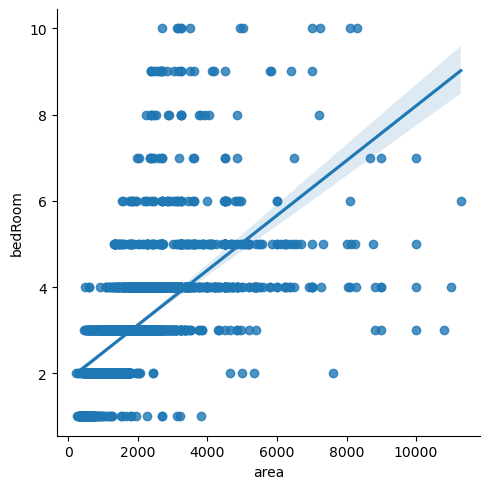

In [102]:
sns.lmplot(x='area',y='bedRoom',data=df);

In [103]:
df.to_csv('gurgaon_properties_outliers_treated.csv',index=False)